# PRiSM Example: UNOS Heart Transplant Data

This notebook demonstrates the PRiSM (Partial Responses in Structured Models) method, which is designed to transform black-box classifiers into inherently interpretable models without compromising predictive performance. This approach is particularly valuable in high-stakes applications where understanding the model's decision-making process is crucial.

The method addresses a key challenge in machine learning: the trade-off between model complexity and interpretability. It allows us to create models that are both accurate and transparent. In this example, we'll use the UNOS (United Network for Organ Sharing) heart transplant dataset to illustrate the PRiSM method.

Here, the target outcome we are modelling is "oneyearmort", which refers to:

- 0: a patient who survived at least one year after heart transplant
- 1: a patient who died within one year of heart transplant

We would like to use the available features to model the likelihood of one-year mortality after heart transplantation, and understand how each feature contributes to that likelihood.



In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from prism.config import PROCESSED_DATA_DIR, MODELS_DIR
from prism.preprocessing import normalize, feature_summary, plot_feature_histograms
from prism.maskedmlp import train_mlp_batched, train_maskedmlp
from prism.partial_responses import partial_responses
from prism.response_plot import plot_partial_responses
from prism.nomogram import nomogram, display_nomograms_side_by_side
from prism.lasso import lasso
from prism.device_tools import get_device, get_num_cpu_workers
from prism.metrics import evaluate_model_performance, compare_model_performance

2024-09-02 16:34:03.979 | INFO     | prism.config:<module>:11 - PROJ_ROOT path is: C:\Users\localuser\PRiSM\prism_github


In [2]:
%reload_ext autoreload

## 1. Setup and Imports

First, we need to import the necessary libraries and set up our environment.

We set up our computational device (CPU or GPU if available) and set a random seed for reproducibility.

We'll use the 'dirac' method for partial responses, which is one of two methods (the other being 'lebesgue') for calculating partial responses. The Dirac method calculates the effect of each feature individually, which can be computationally efficient but may miss some complex interactions.



We set up our computational device (CPU or GPU if available) and set a random seed for reproducibility.

Two methods, 'lebesgue' and 'dirac', can be used to calculate partial responses. The Lebesgue method uses an average over the predicted surface, which can be more stable for some datasets, but more computationally intensive. If you're working with a bigger dataset, or low compute resources, starting with 'dirac' may be better.

In [3]:
# Set device to 'cpu', or GPU ('cuda' for NVIDIA, 'mps' for Apple Silicon)
# By default, we select the best available device
device = get_device() 
print(f"Using device: {device}")

# Set random seed for reproducibility
random_seed = 257
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# Set method and other parameters
partial_response_method = 'lebesgue'
SAVE_METRICS = True

# TODO: setup model saving.
SAVE_MODELS = False

Using device: cuda


For multithreading compute-intensive tasks, the recommended number of workers for GPU processing is 1, otherwise for CPU stick to the default (number of logical cores - 1). However, depending on your hardware, you may want to experiment.

In [4]:
if device != 'cpu':
    max_workers = 1
else:
    max_workers = get_num_cpu_workers()
print(f"max_workers = {max_workers}")

max_workers = 1


## 2. Load and Preprocess Data

Next, we load the UNOS heart transplant data and perform necessary preprocessing steps.



In [5]:
# Load data
data_train = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_train.csv'))
data_test = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_test.csv'))
data_val = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_val.csv'))

# Drop id column
data_train.drop('trr_id_code', axis=1, inplace=True)
data_test.drop('trr_id_code', axis=1, inplace=True)
data_val.drop('trr_id_code', axis=1, inplace=True)

target_col = 'oneyearmort'

X_train = data_train.drop(target_col, axis=1)
y_train = data_train[target_col]

X_test = data_test.drop(target_col, axis=1)
y_test = data_test[target_col]

X_val = data_val.drop(target_col, axis=1)
y_val = data_val[target_col]

# Normalize the data
X_train_normalized, X_test_normalized = normalize(X_train, X_test)
X_val_normalized = normalize(X_val)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_normalized.values, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test_normalized.values, dtype=torch.float32, device=device)
X_val_tensor = torch.tensor(X_val_normalized.values, dtype=torch.float32, device=device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32, device=device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32, device=device)

feature_names = [
    'don age',
    'don isch time min',
    'rec age',
    'rec creat',
    'rec infect 2wk',
    'rec vent',
    'rec sex',
    'tx year',
    'ICM',
    'NICM',
    'prior tx'
]

## 3. Data Overview

Before building our models, let's get an overview of the data.



In [6]:
print("Shape of training data:", X_train.shape)
print("Shape of testing data:", X_test.shape)
print("Shape of validation data:", X_val.shape)
print(f"\nClass distribution in training set ({X_train['tx_year'].min()} - {X_train['tx_year'].max()}):")
print(y_train.value_counts(normalize=True))
print(f"\nClass distribution in test set ({X_test['tx_year'].min()} - {X_test['tx_year'].max()}):")
print(y_test.value_counts(normalize=True))
print(f"\nClass distribution in validation set ({X_val['tx_year'].min()} - {X_val['tx_year'].max()}):")
print(y_val.value_counts(normalize=True))

Shape of training data: (31315, 11)
Shape of testing data: (6120, 11)
Shape of validation data: (4750, 11)

Class distribution in training set (1997 - 2013):
oneyearmort
0    0.877024
1    0.122976
Name: proportion, dtype: float64

Class distribution in test set (2014 - 2016):
oneyearmort
0    0.89281
1    0.10719
Name: proportion, dtype: float64

Class distribution in validation set (2017 - 2018):
oneyearmort
0    0.900842
1    0.099158
Name: proportion, dtype: float64


In [7]:
feature_stats = feature_summary(X_train, categorical_threshold=15)
print("Feature Statistics:")
print(feature_stats)

Feature Statistics:
                        Data Type  Non-Null Count  Null Count         Mean  \
donage                      int64           31315           0    32.091043   
donischemictimeminutes    float64           31315           0   189.745752   
recageyear                  int64           31315           0    52.359412   
reccreatininemostrecent   float64           31315           0   119.943712   
recinfections2weeks         int64           31315           0     0.106754   
recventilator               int64           31315           0     0.025770   
recsex                      int64           31315           0     0.237043   
tx_year                     int64           31315           0  2005.084943   
diagnICM                    int64           31315           0     0.437841   
diagnNICM                   int64           31315           0     0.466741   
recpriortx                  int64           31315           0     0.034424   

                             Median    Std 

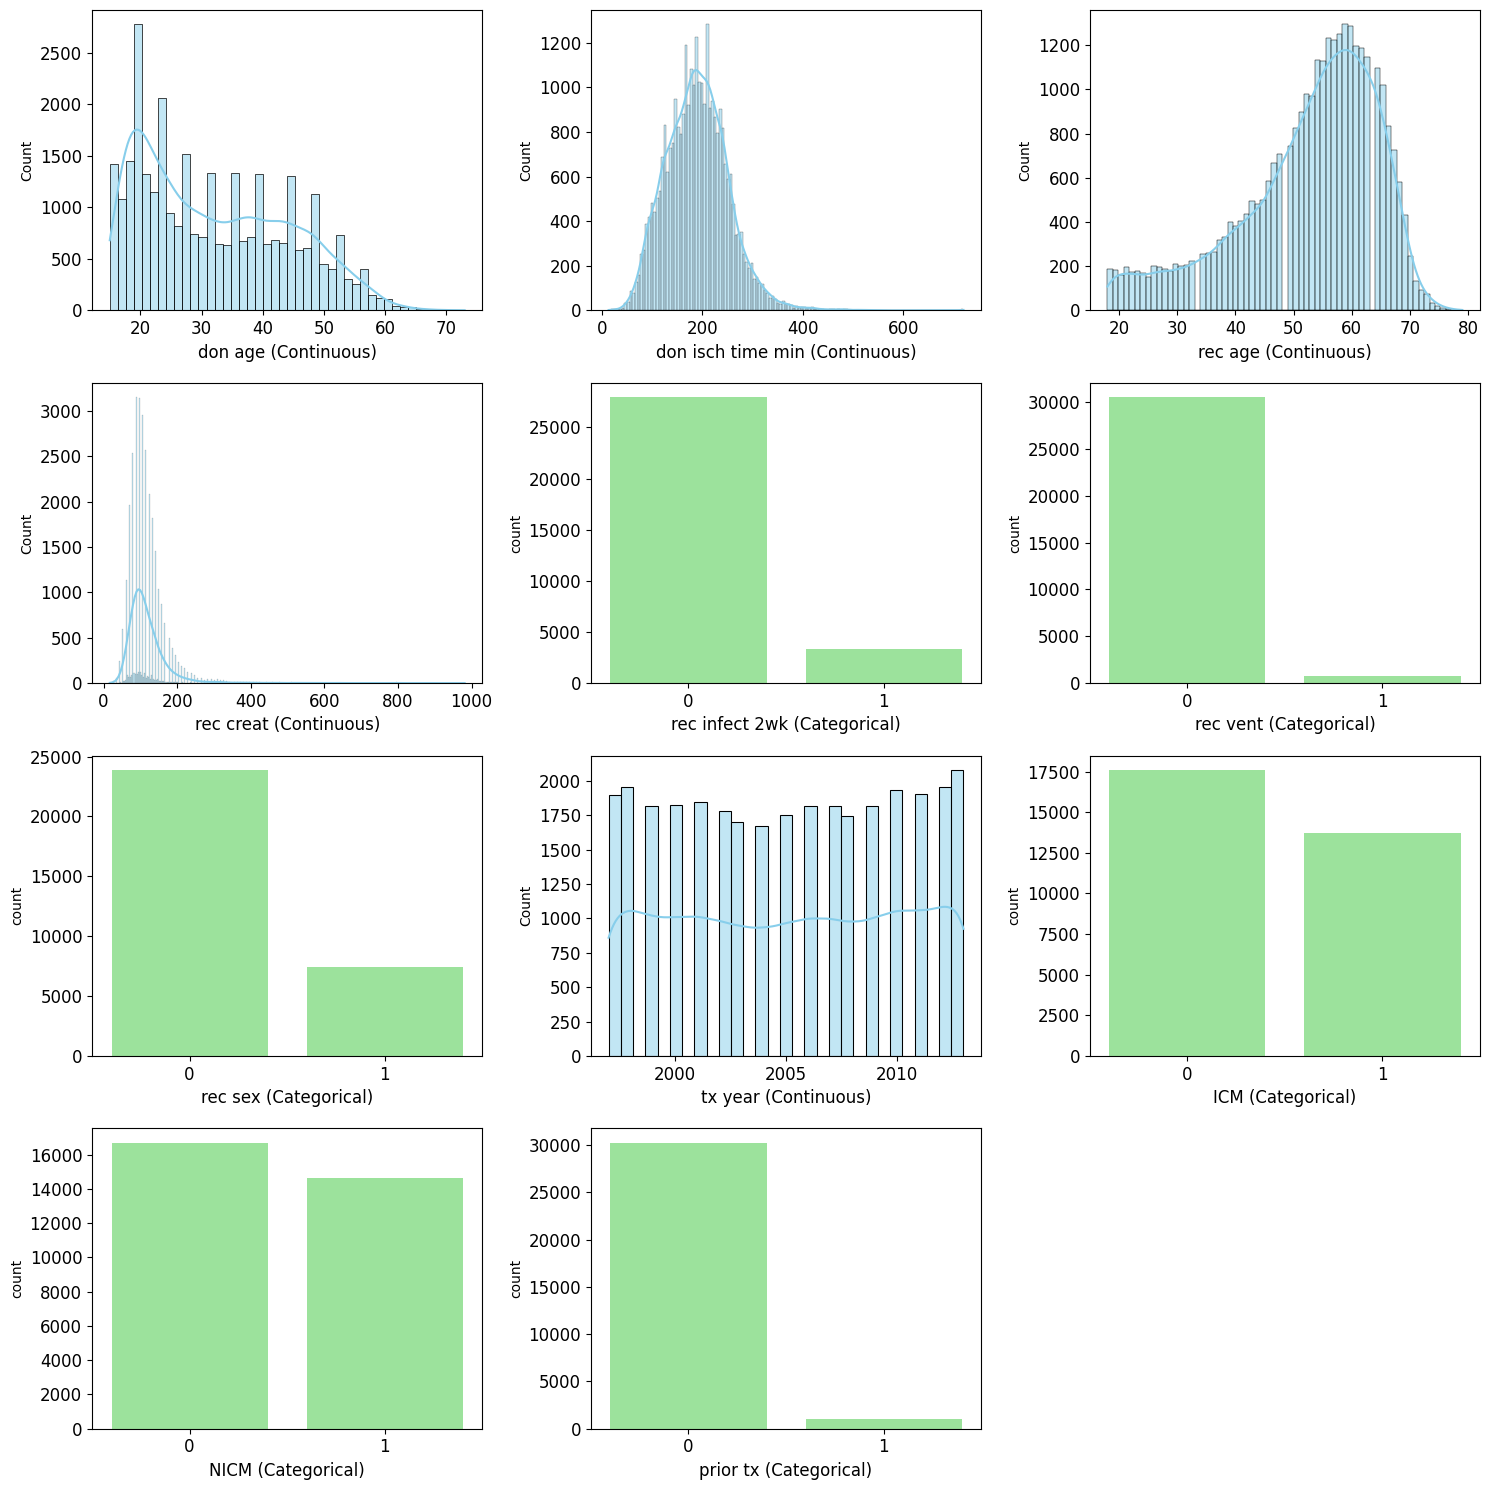

<module 'matplotlib.pyplot' from 'c:\\Users\\localuser\\PRiSM\\prism_github\\venv_prism\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [8]:
plot_feature_histograms(X_train, feature_stats, figsize=(15,15), feature_names=feature_names)

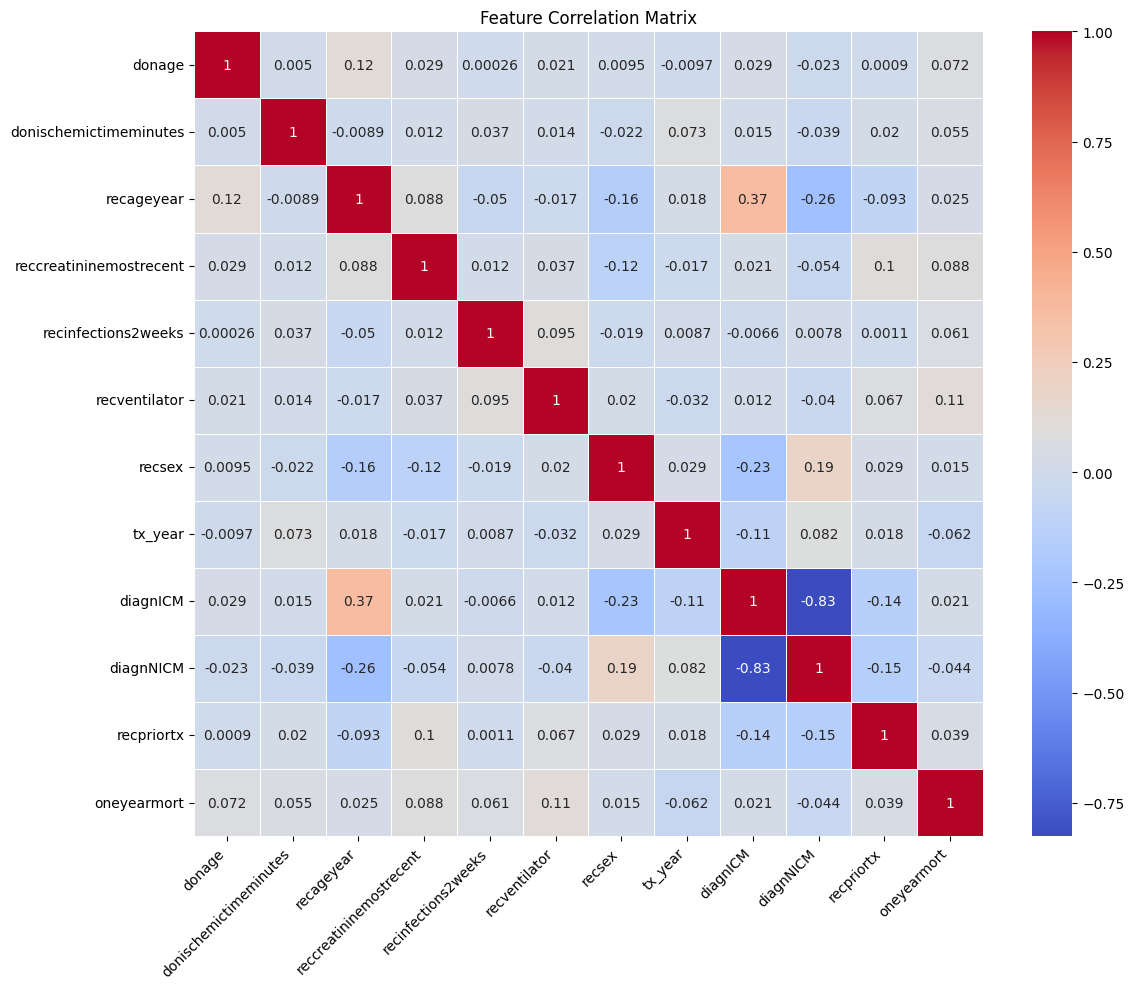

In [9]:
# Correlation matrix
correlation_matrix = pd.concat([X_train, y_train], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Train Initial Black Box Model (MLP)

We start by training a black box model, in this case, a Multi-Layer Perceptron (MLP) with 10 nodes in the hidden layer. This model serves as our baseline and represents the type of hard-to-interpret model that is often used in machine learning.



In [10]:
mlp_hyperparameters = {
    'n_hidden': 10,
    'weight_decay': 1e-5,
    'lr': 0.001,
    'patience': 50,
    'tolerance': 0.0001,
    'batch_size': 1024,
    'device': device,
    'seed': random_seed
}

blackbox_model = train_mlp_batched(X_train_normalized, y_train, X_test_normalized, y_test, **mlp_hyperparameters)

Epoch 0: Train loss 0.6690, Test loss 0.6166
Epoch 1: Train loss 0.5749, Test loss 0.5303
Epoch 2: Train loss 0.5062, Test loss 0.4680
Epoch 3: Train loss 0.4573, Test loss 0.4224
Epoch 4: Train loss 0.4240, Test loss 0.3906
Epoch 5: Train loss 0.4014, Test loss 0.3693
Epoch 6: Train loss 0.3869, Test loss 0.3563
Epoch 7: Train loss 0.3782, Test loss 0.3485
Epoch 8: Train loss 0.3726, Test loss 0.3440
Epoch 9: Train loss 0.3694, Test loss 0.3416
Epoch 10: Train loss 0.3667, Test loss 0.3402
Epoch 11: Train loss 0.3653, Test loss 0.3395
Epoch 12: Train loss 0.3644, Test loss 0.3393
Epoch 13: Train loss 0.3640, Test loss 0.3392
Epoch 14: Train loss 0.3631, Test loss 0.3391
Epoch 15: Train loss 0.3621, Test loss 0.3391
Epoch 16: Train loss 0.3624, Test loss 0.3392
Epoch 17: Train loss 0.3617, Test loss 0.3392
Epoch 18: Train loss 0.3613, Test loss 0.3393
Epoch 19: Train loss 0.3611, Test loss 0.3392
Epoch 20: Train loss 0.3611, Test loss 0.3393
Epoch 21: Train loss 0.3608, Test loss 0.339


---- Model Performance Metrics MLP - training data ----
Threshold (prevalence) set to: 0.123
AUROC:		0.657 (95% CI: 0.648-0.667) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.652 (Proportion of correct predictions)
Precision:	0.191 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.564 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.285 (Harmonic mean of precision and recall)
--------------------------------------------


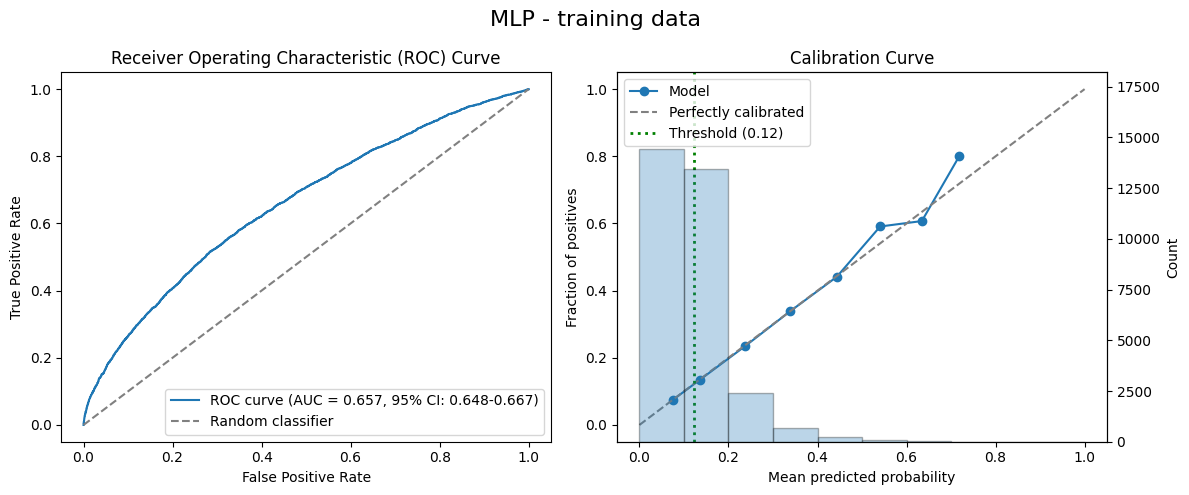


---- Model Performance Metrics MLP - test data ----
Threshold (prevalence) set to: 0.123
AUROC:		0.601 (95% CI: 0.578-0.623) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.797 (Proportion of correct predictions)
Precision:	0.175 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.241 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.203 (Harmonic mean of precision and recall)
--------------------------------------------


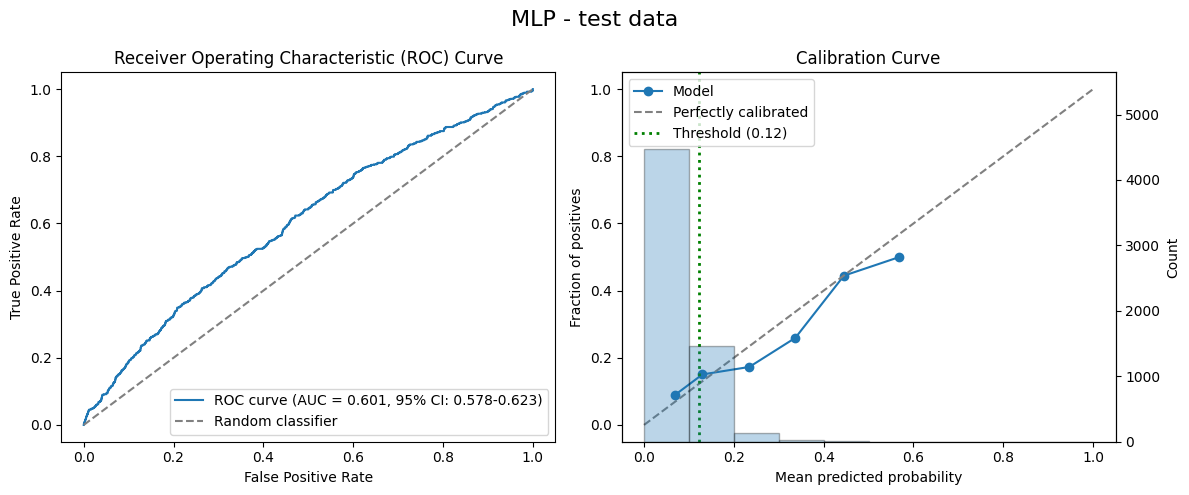

In [11]:
y_pred_train_blackbox = blackbox_model.predict(X_train_tensor)
y_pred_test_blackbox = blackbox_model.predict(X_test_tensor)

# Evaluate MLP
results_mlp_train = evaluate_model_performance(y_train, y_pred_train_blackbox, y_train, title="MLP - training data")
results_mlp_test = evaluate_model_performance(y_test, y_pred_test_blackbox, y_train, title="MLP - test data")

## 5. Calculate Partial Responses

Now we calculate partial responses for our black box model. This is a key step in the PRiSM method. Partial responses help us understand how individual features or pairs of features contribute to the model's predictions, making the black box model more interpretable.



In [12]:
partial_responses_params = {
    'x_train': X_train_tensor,
    'method': partial_response_method,
    'device': device,
    'batch_size': 512,
    'max_workers': max_workers
}

partial_responses_train = partial_responses(X_train_tensor, blackbox_model, **partial_responses_params)
partial_responses_test = partial_responses(X_test_tensor, blackbox_model, **partial_responses_params)

Main compute device: cuda
Max threads: 1
Batch size: 512
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Univariate 10,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 0,10,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 1,10,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 2,10,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Biva

## 6. Perform LASSO on Partial Responses

We use LASSO (Least Absolute Shrinkage and Selection Operator) to select the most consequential partial responses. This step helps us identify which features or feature interactions contribute most to the model's predictions. A range of regularization strengths (lambda) are used, and for each one a logistic regression model with LASSO regularization is trained and evaluated. Based on the results, we can choose the most suitable lambda, balancing model performance against the total number of selected features.



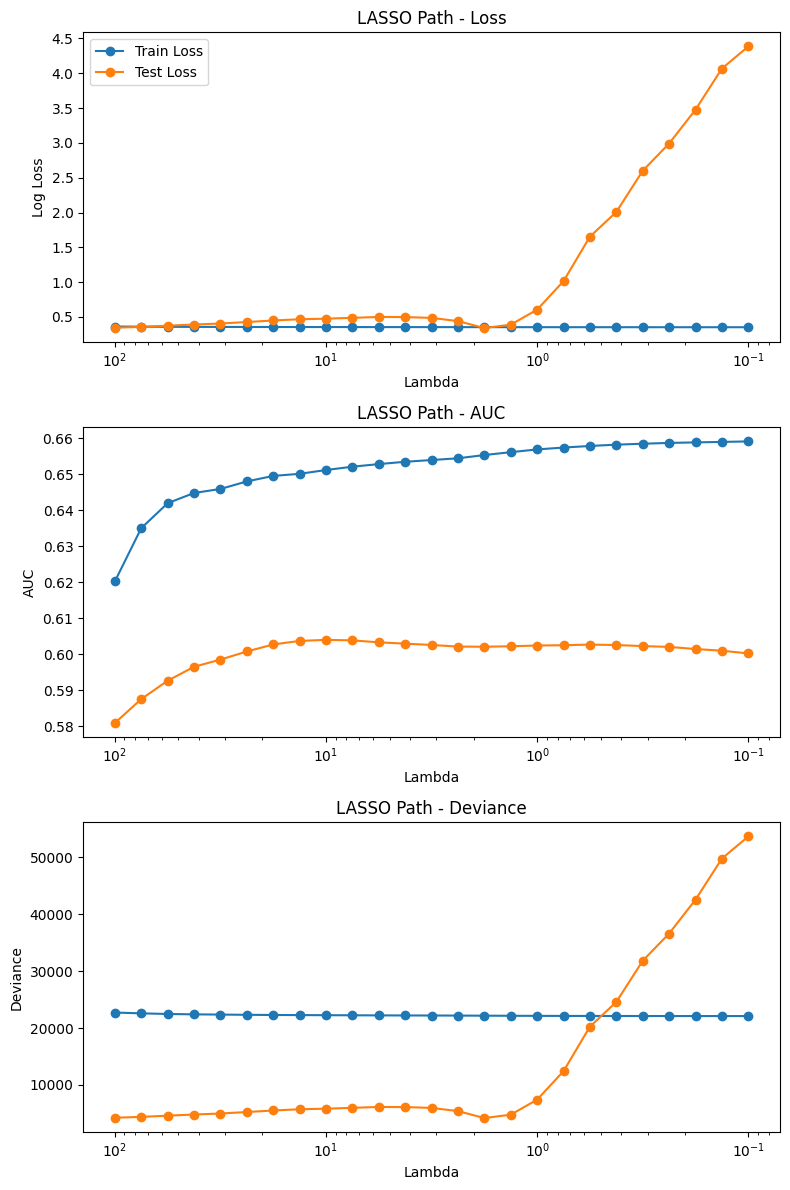

All fits converged successfully.


In [13]:
lasso_results = lasso(
    partial_responses_train, 
    partial_responses_test, 
    y_train, 
    y_test, 
    feature_names=feature_names,
    nlambda=25, 
    min_lambda=0.1,
    max_lambda=100,
    batch_size=2,
    seed=random_seed
)

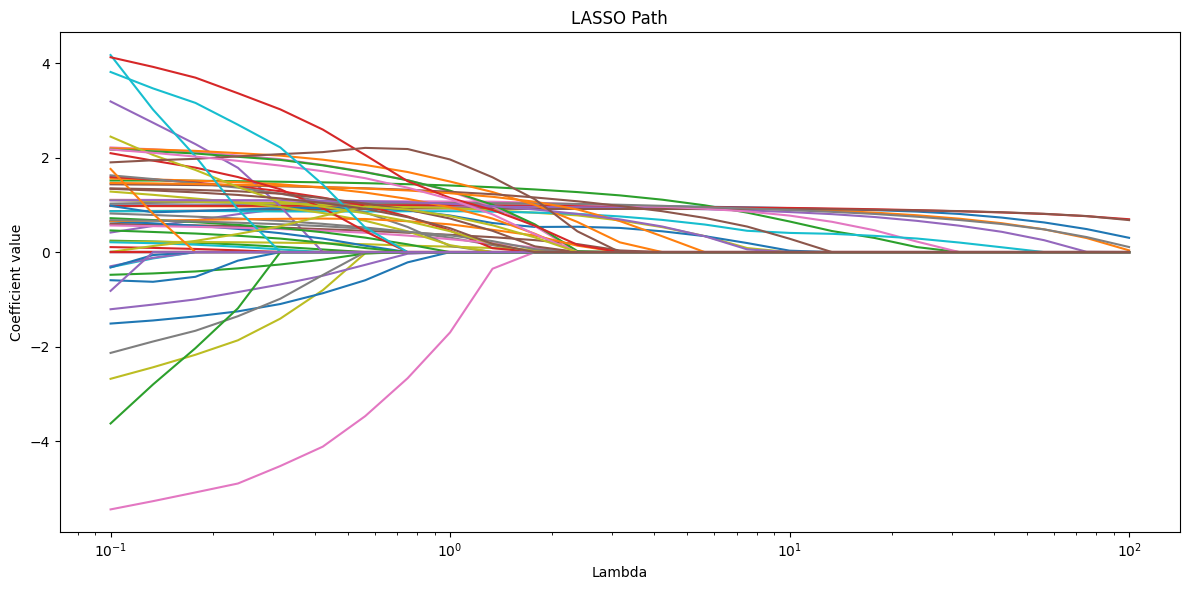

In [14]:
lasso_results.plot_lambda_path()

In [15]:
# lasso_results.select_lambda_max_test_auc()

# Alternatively, manually select lambda as needed
lasso_results.select_lambda(9)

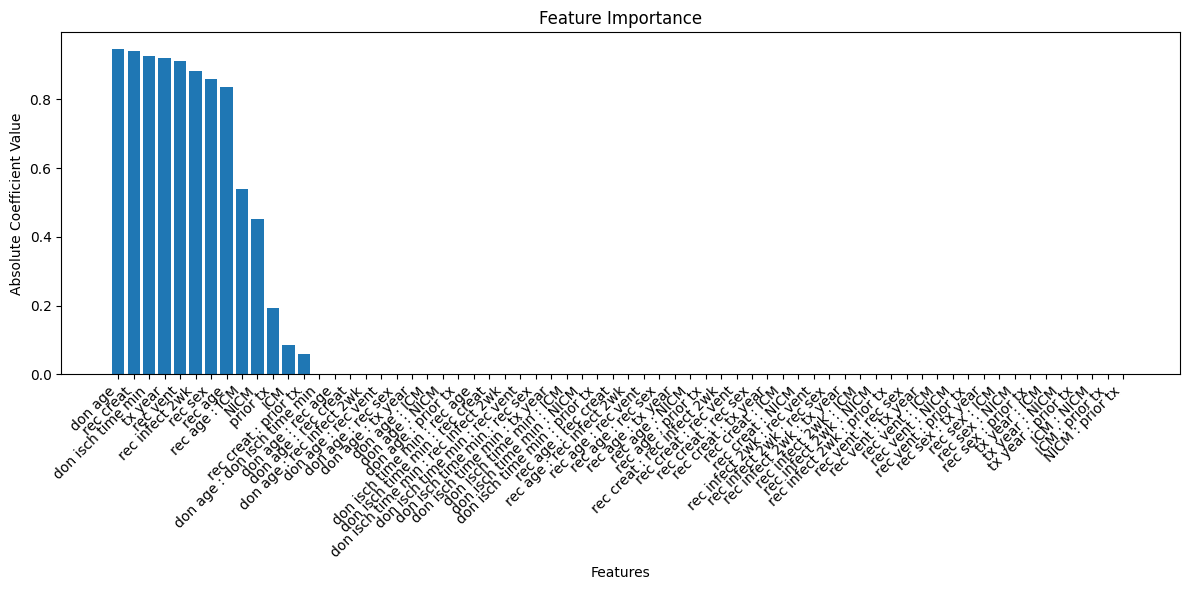

In [16]:

lasso_results.plot_feature_importance()

## 7. View Selected Partial Responses and Generate Nomogram

First, we visualize the contribution of each partial response selected with LASSO to the target value.

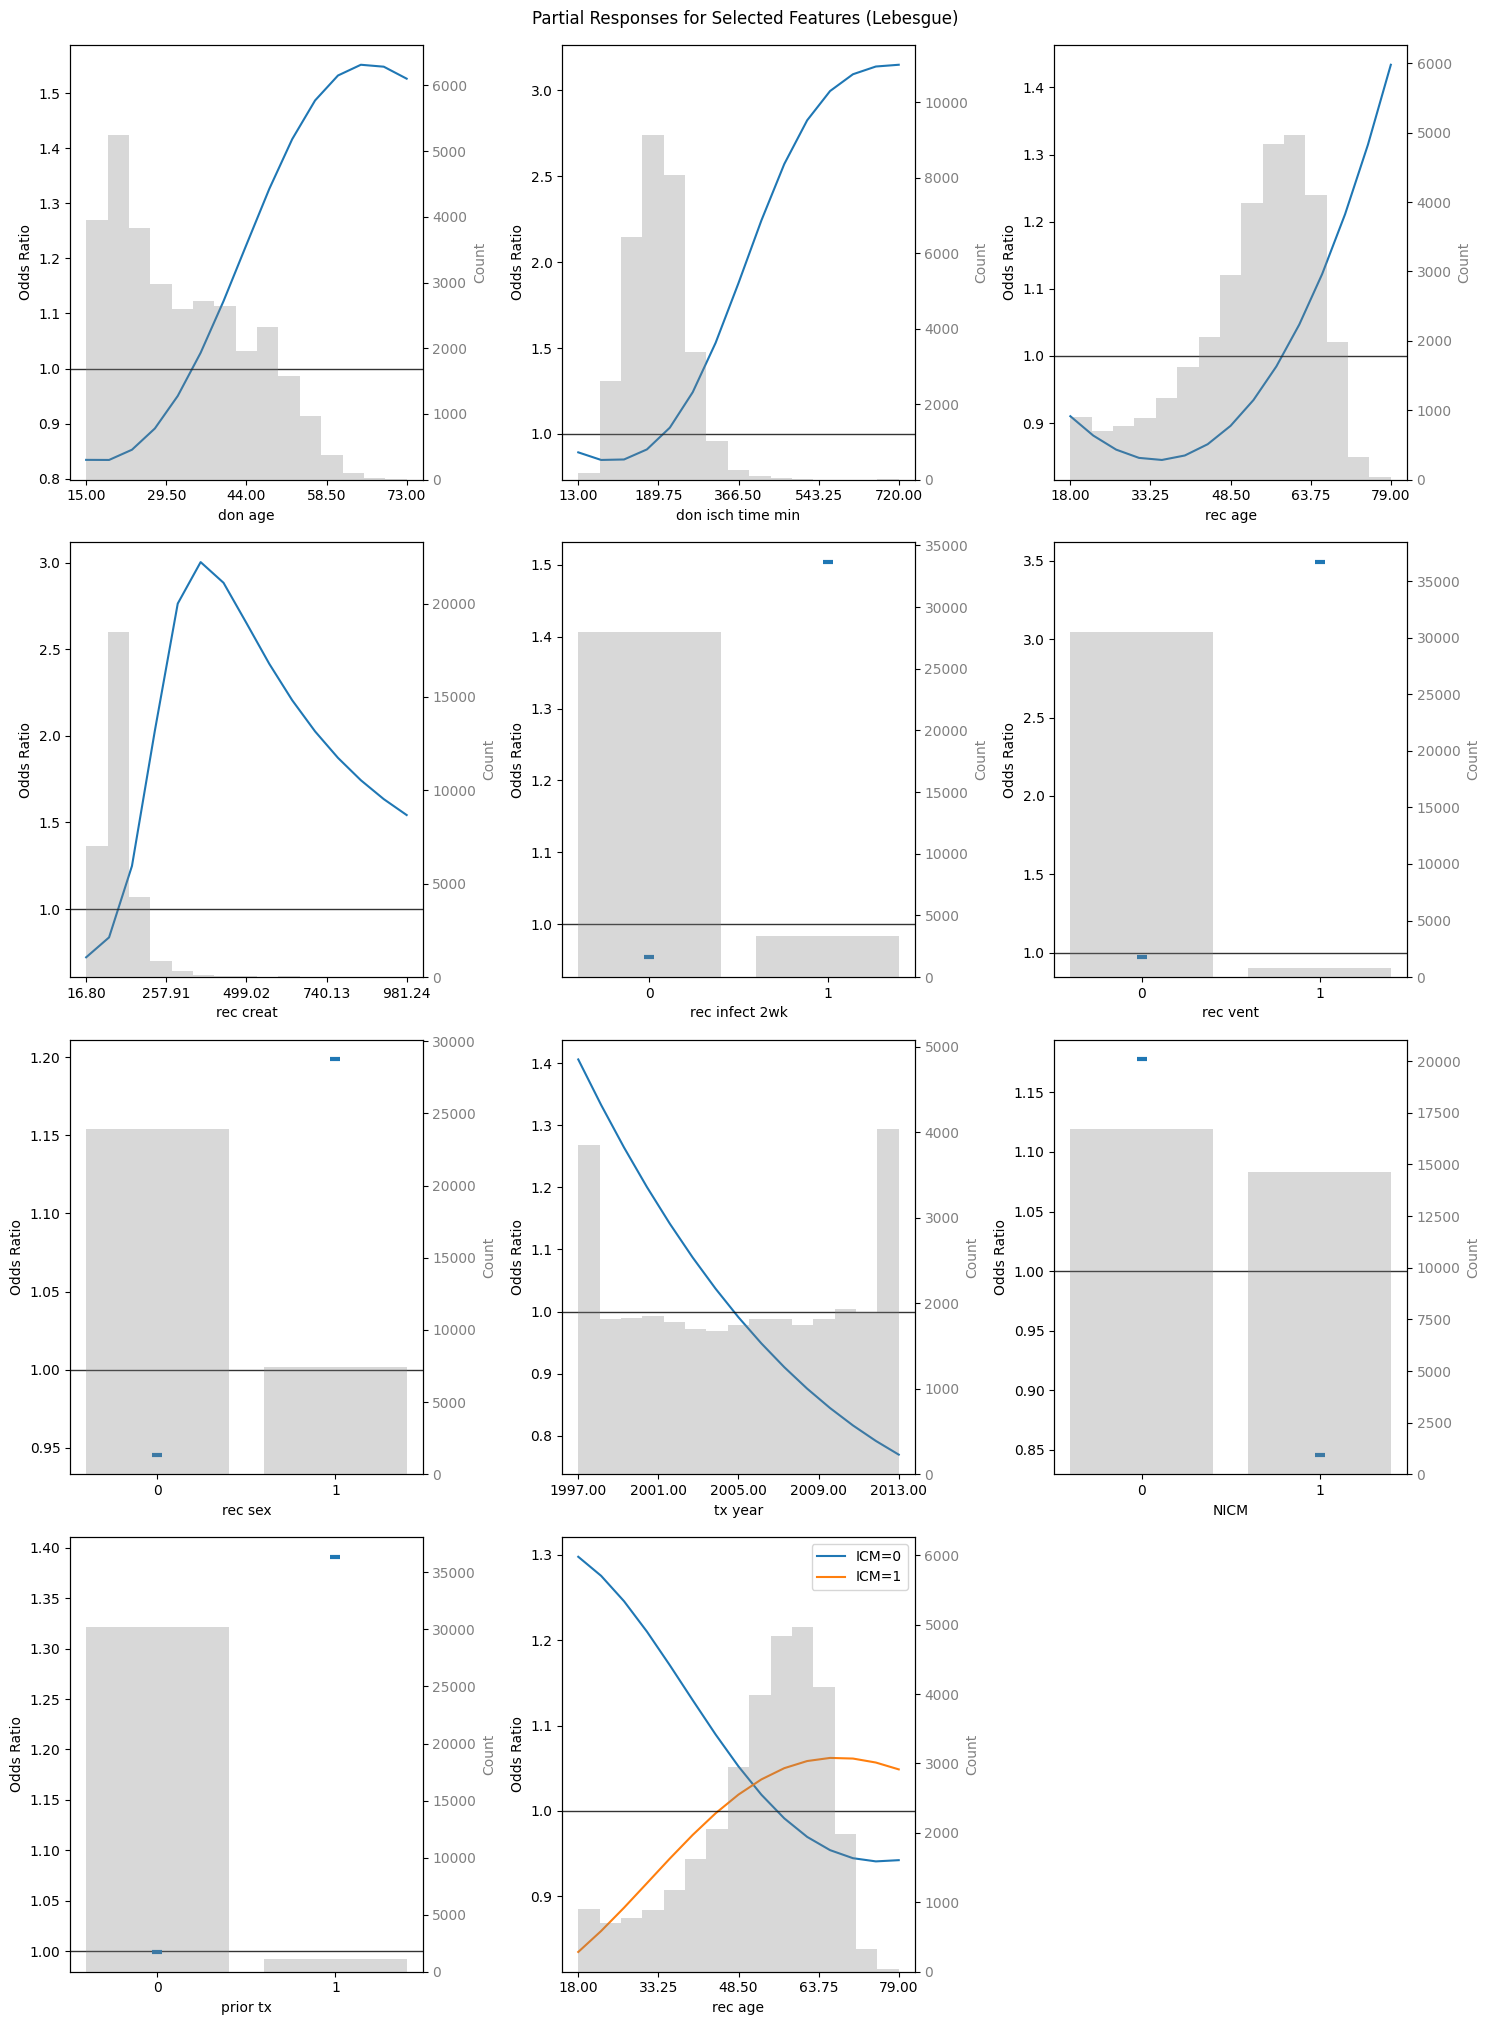

In [17]:
fig_blackbox = plot_partial_responses(
    lasso_results,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    blackbox_model,
    n_steps=15,
    sd_scale=2,
    method=partial_response_method,
    device=device,
    categorical_threshold=15,
    subtract_univariate=True,                    
    figsize=(15,20),
    show_fig=True,
    return_fig=True,
    use_odds_ratio=True
)


We can also visualize the contribution of each partial response using a nomogram. Nomograms are particularly useful in clinical settings as they provide an intuitive visual representation of a model's decision-making process.



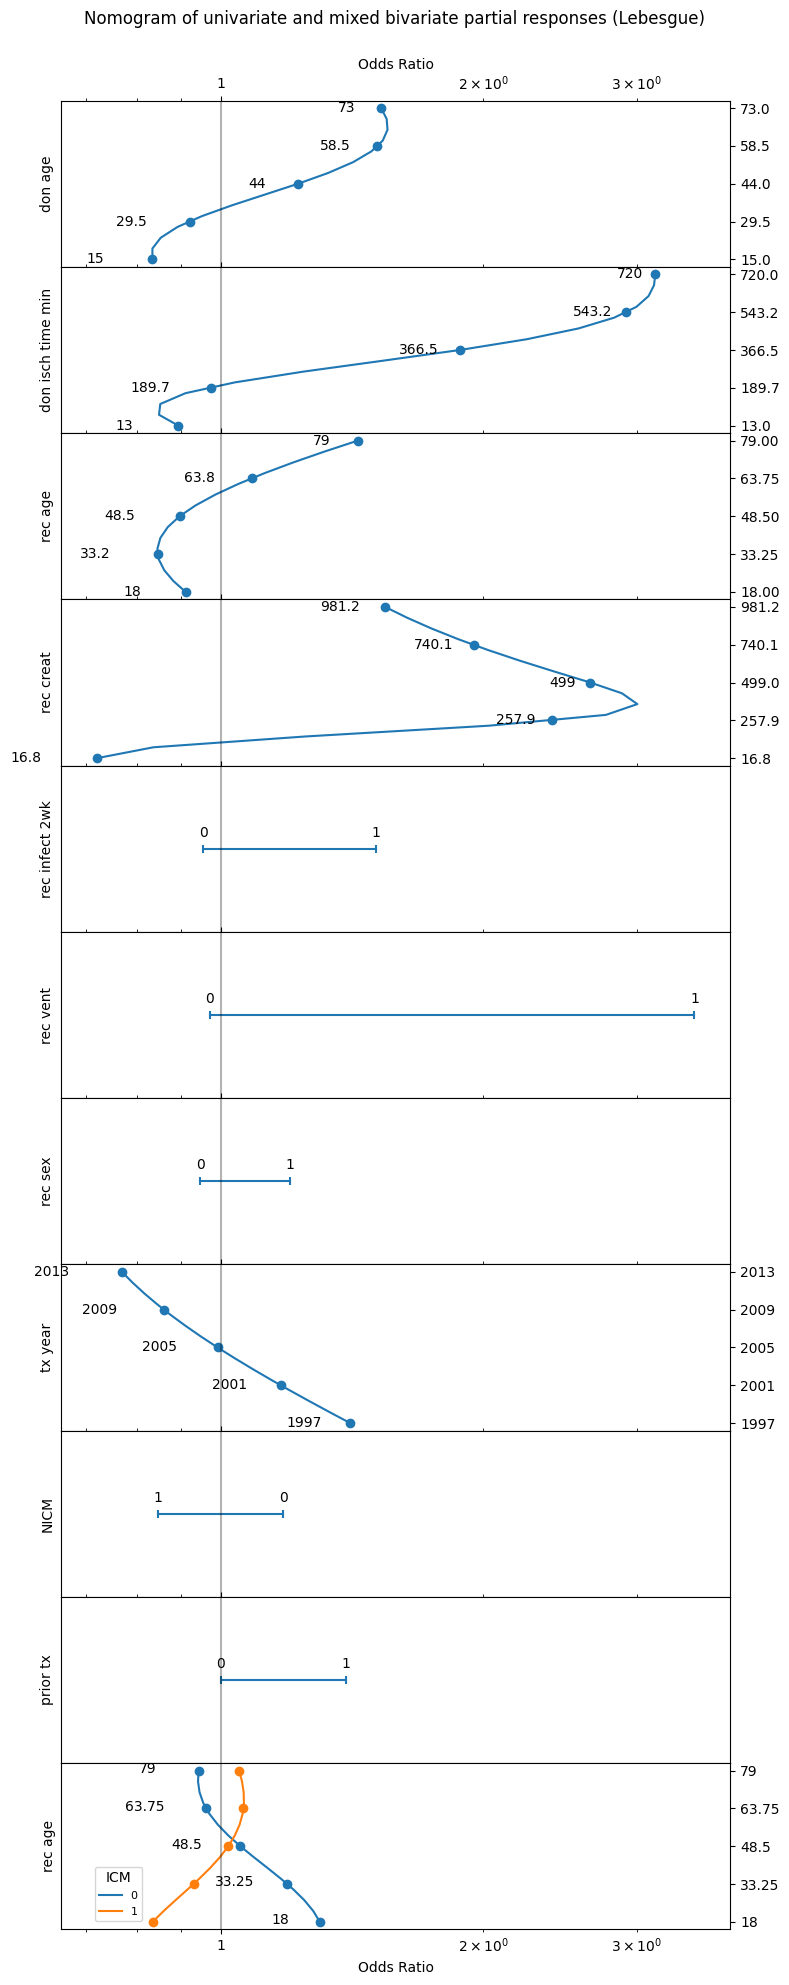

In [18]:
nomogram_params = {
    'n_steps': 15,
    'sd_scale': 2,
    'method': partial_response_method,
    'device': device,
    'categorical_threshold': 15,
    'subtract_univariate': True,
    'return_fig': True,
    'use_odds_ratio': True
}

nomogram_results = nomogram(
    lasso_results,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    blackbox_model,
    **nomogram_params
)
nomogram_main_mlp = nomogram_results[6]
nomogram_non_mixed_mlp = nomogram_results[7]

## 8. Train Partial Response Network (PRN)

Now we train a Partial Response Network based on the selected features. The PRN is a type of neural network that incorporates the interpretability of partial responses while maintaining the predictive power of the original black box model.

From the results of the lasso feature selection, we create an input mask for the PRN. The mask is a binary matrix that determines which input features connect to which hidden nodes (subnets) in the network. This enforces the network structure based on selected features.

The PRN uses a subnet architecture, where groups of hidden nodes are dedicated to specific features or feature interactions:

- Univariate subnets: Handle individual feature effects
- Bivariate subnets: Capture interactions between two features
- The number of nodes per subnet is controlled by the subnet_nodes parameter in `mlpmask_pytorch` (default 5)

This gives us a resulting network structure as follows:

- Input layer: Original features
- Hidden layer: Structured into subnets based on the mask
- Output layer: Single node for binary classification

The resulting PRN maintains interpretability because each subnet corresponds to a specific feature or interaction. Therefore, the contribution of each feature/interaction can be analyzed separately, and the overall prediction is a sum of these interpretable components.



Selected features: ['don age', 'don isch time min', 'rec age', 'rec creat', 'rec infect 2wk', 'rec vent', 'rec sex', 'tx year', 'NICM', 'prior tx', 'rec age : ICM']


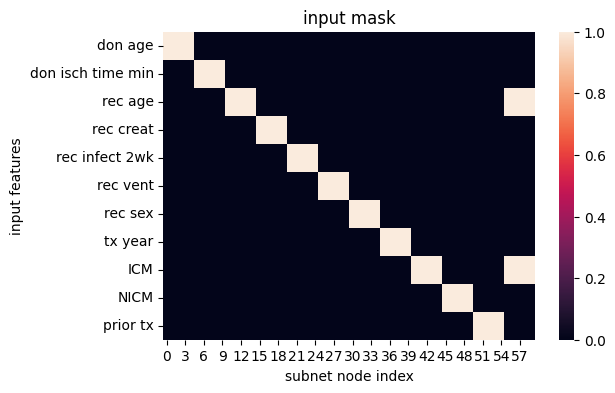

In [19]:
mask, n_features = lasso_results.get_mask()

In [20]:
prn_hyperparameters = {
    'n_hidden': n_features,
    'mask': mask,
    'subnet_nodes': 5,
    'iter': 10000,
    'lr': 0.05,
    'weight_decay': 0.00001,
    'tolerance': 0.0001,
    'patience': 100,
    'device': device,
    'seed': random_seed
}

partial_response_network = train_maskedmlp(X_train_normalized, y_train, X_test_normalized, y_test, **prn_hyperparameters)

Epoch 0, Training loss 0.6397774815559387, Test loss 0.49593019485473633
Epoch 1, Training loss 0.526766836643219, Test loss 0.37622636556625366
Epoch 2, Training loss 0.4034844636917114, Test loss 0.3410705327987671
Epoch 3, Training loss 0.3746626079082489, Test loss 0.3626147508621216
Epoch 4, Training loss 0.4021831452846527, Test loss 0.3887971341609955
Epoch 5, Training loss 0.42837005853652954, Test loss 0.39575478434562683
Epoch 6, Training loss 0.42989999055862427, Test loss 0.3839559555053711
Epoch 7, Training loss 0.41042307019233704, Test loss 0.3624988794326782
Epoch 8, Training loss 0.38338083028793335, Test loss 0.3434027433395386
Epoch 9, Training loss 0.3658364713191986, Test loss 0.3374348282814026
Epoch 10, Training loss 0.3712558448314667, Test loss 0.3432115316390991
Epoch 11, Training loss 0.3910899758338928, Test loss 0.3451085090637207
Epoch 12, Training loss 0.39637643098831177, Test loss 0.33946576714515686
Epoch 13, Training loss 0.38176169991493225, Test los


---- Model Performance Metrics PRN - train data ----
Threshold (prevalence) set to: 0.123
AUROC:		0.651 (95% CI: 0.641-0.661) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.646 (Proportion of correct predictions)
Precision:	0.187 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.561 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.280 (Harmonic mean of precision and recall)
--------------------------------------------


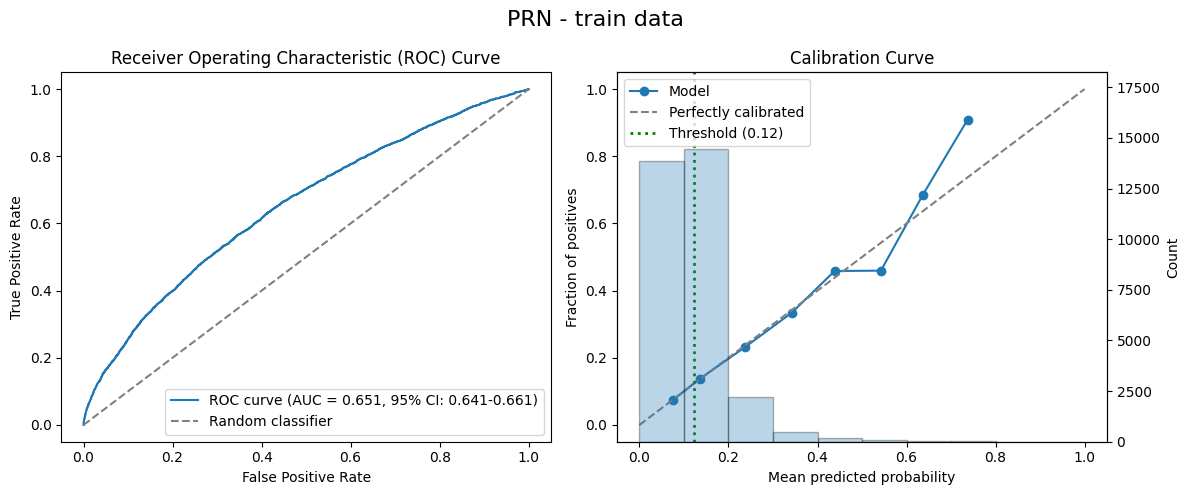


-------- Model Performance Comparison --------
Threshold (prevalence) set to: 0.123

MLP:
AUROC:		0.601 (95% CI: 0.578-0.622)
Accuracy:	0.797
Precision:	0.175
Recall:		0.241
F1 Score:	0.203

PRN:
AUROC:		0.602 (95% CI: 0.578-0.624)
Accuracy:	0.803
Precision:	0.174
Recall:		0.223
F1 Score:	0.195
------------------------------------------------


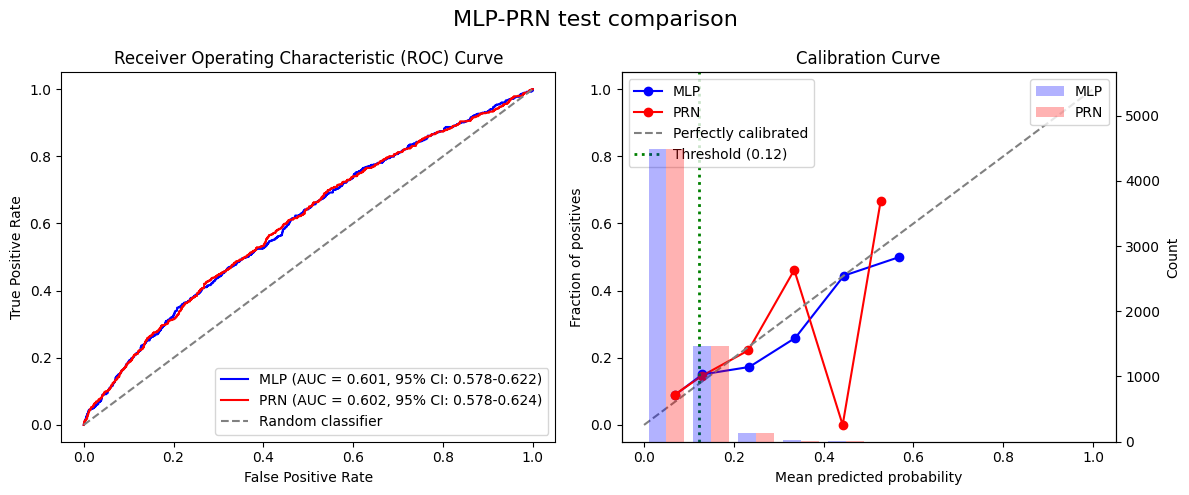

In [21]:
# Evaluate PRN on training data
y_pred_train_prn = partial_response_network.predict(X_train_tensor, device=device)

results_prn_train = evaluate_model_performance(y_train, y_pred_train_prn, y_train, title="PRN - train data")

# Evaluate PRN on test data and compare to MLP (blackbox)
y_pred_test_prn = partial_response_network.predict(X_test_tensor, device=device)

results_prn_mlp_test = compare_model_performance(y_test, y_pred_test_blackbox, y_pred_test_prn, y_train=y_train, model_names=("MLP","PRN"), title="MLP-PRN test comparison")

## 9. LASSO on PRN

We perform LASSO again, this time on the Partial Response Network to isolate the most important features and interactions.



In [22]:
partial_responses_params_prn = {
    'x_train': X_train_tensor,
    'method': partial_response_method,
    'device': device,
    'batch_size': 256,
    'max_workers': max_workers
}

partial_responses_train_prn = partial_responses(X_train_tensor, partial_response_network, **partial_responses_params_prn)
partial_responses_test_prn = partial_responses(X_test_tensor, partial_response_network, **partial_responses_params_prn)

Main compute device: cuda
Max threads: 1
Batch size: 256
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Univariate 10,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 0,10,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 1,10,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 2,10,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Biva

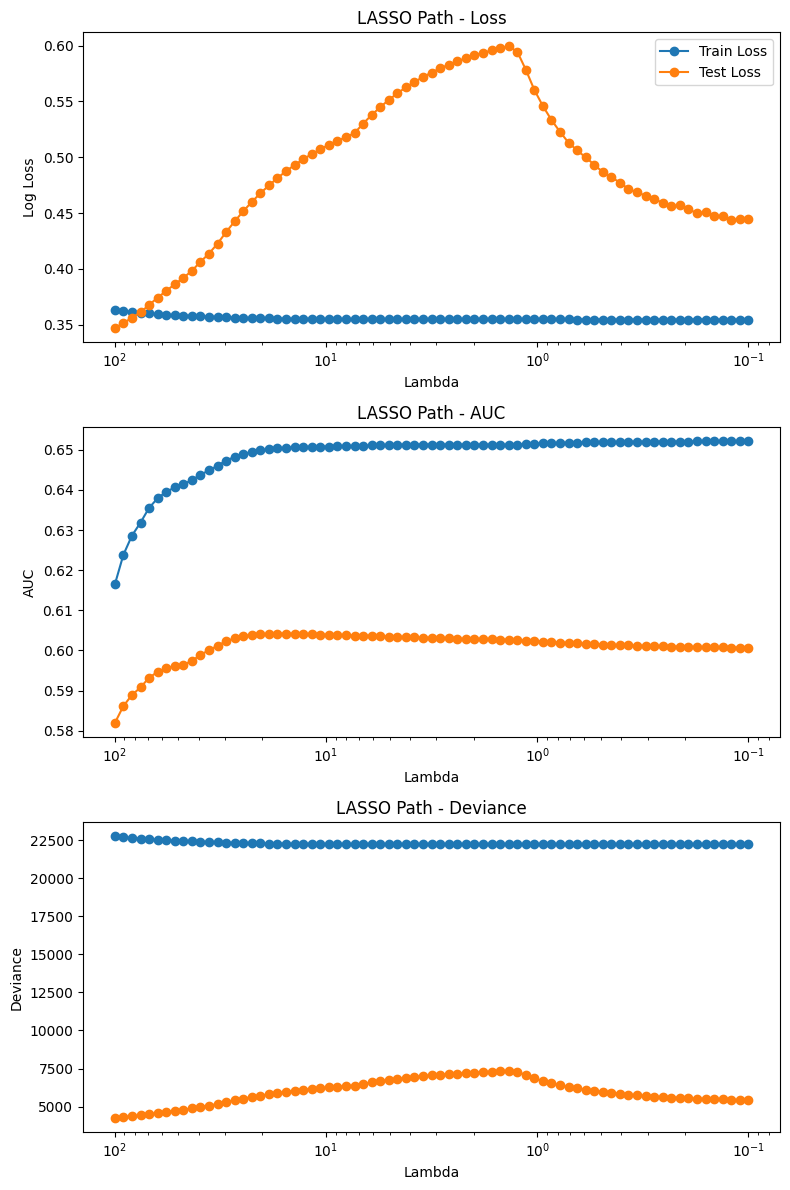

All fits converged successfully.


In [23]:
lasso_results_prn = lasso(
    partial_responses_train_prn, 
    partial_responses_test_prn, 
    y_train, 
    y_test, 
    feature_names=feature_names,
    nlambda=75, 
    min_lambda=0.1,
    max_lambda=100,
    batch_size=2,
    seed=random_seed
)

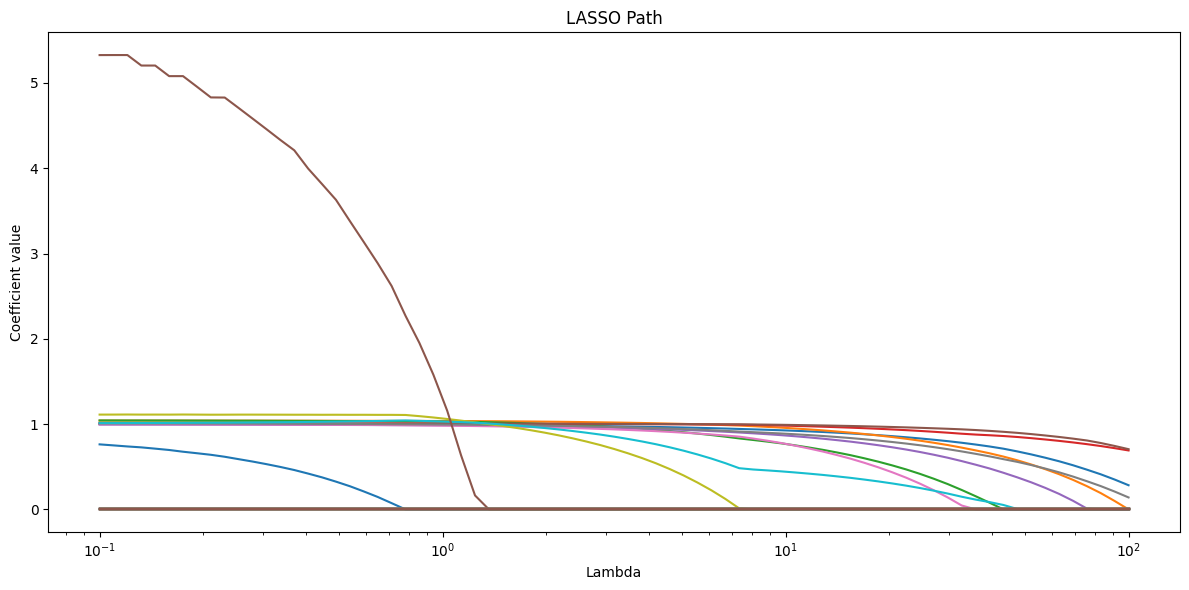

In [24]:
lasso_results_prn.plot_lambda_path()

Selected lambda index: 20
Selected lambda value: 15.4593
Corresponding test AUC: 0.6042


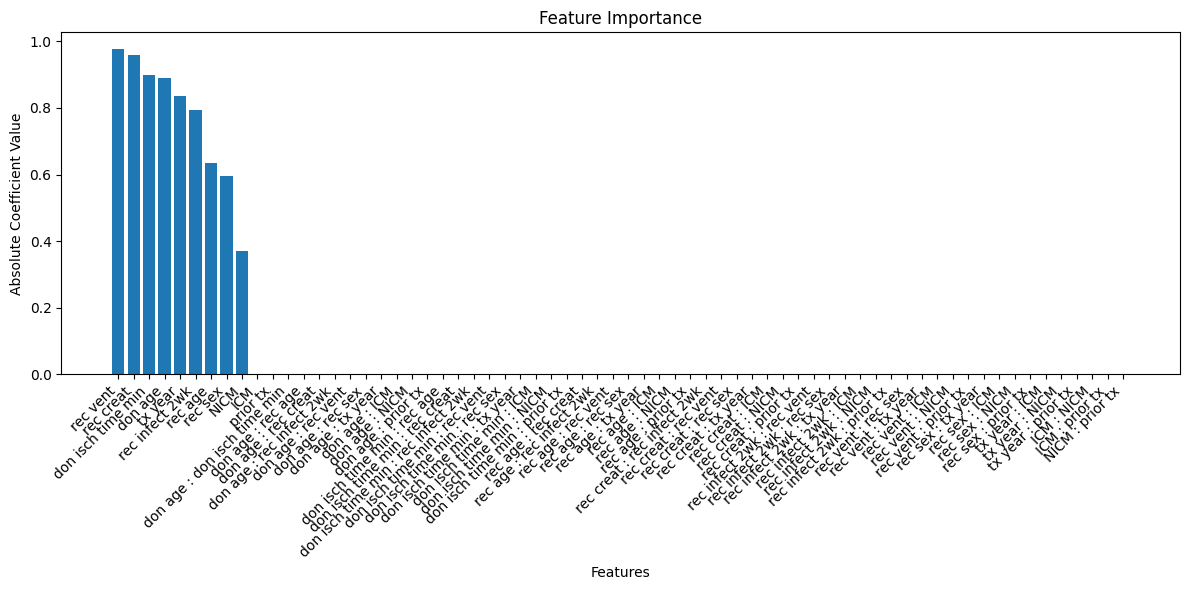

In [25]:
lasso_results_prn.select_lambda_max_test_auc()

# Alternatively, manually select lambda as needed
# lasso_results_prn.select_lambda(20)

lasso_results_prn.plot_feature_importance()

## 10. Generate Final Partial Response Plots and Nomogram

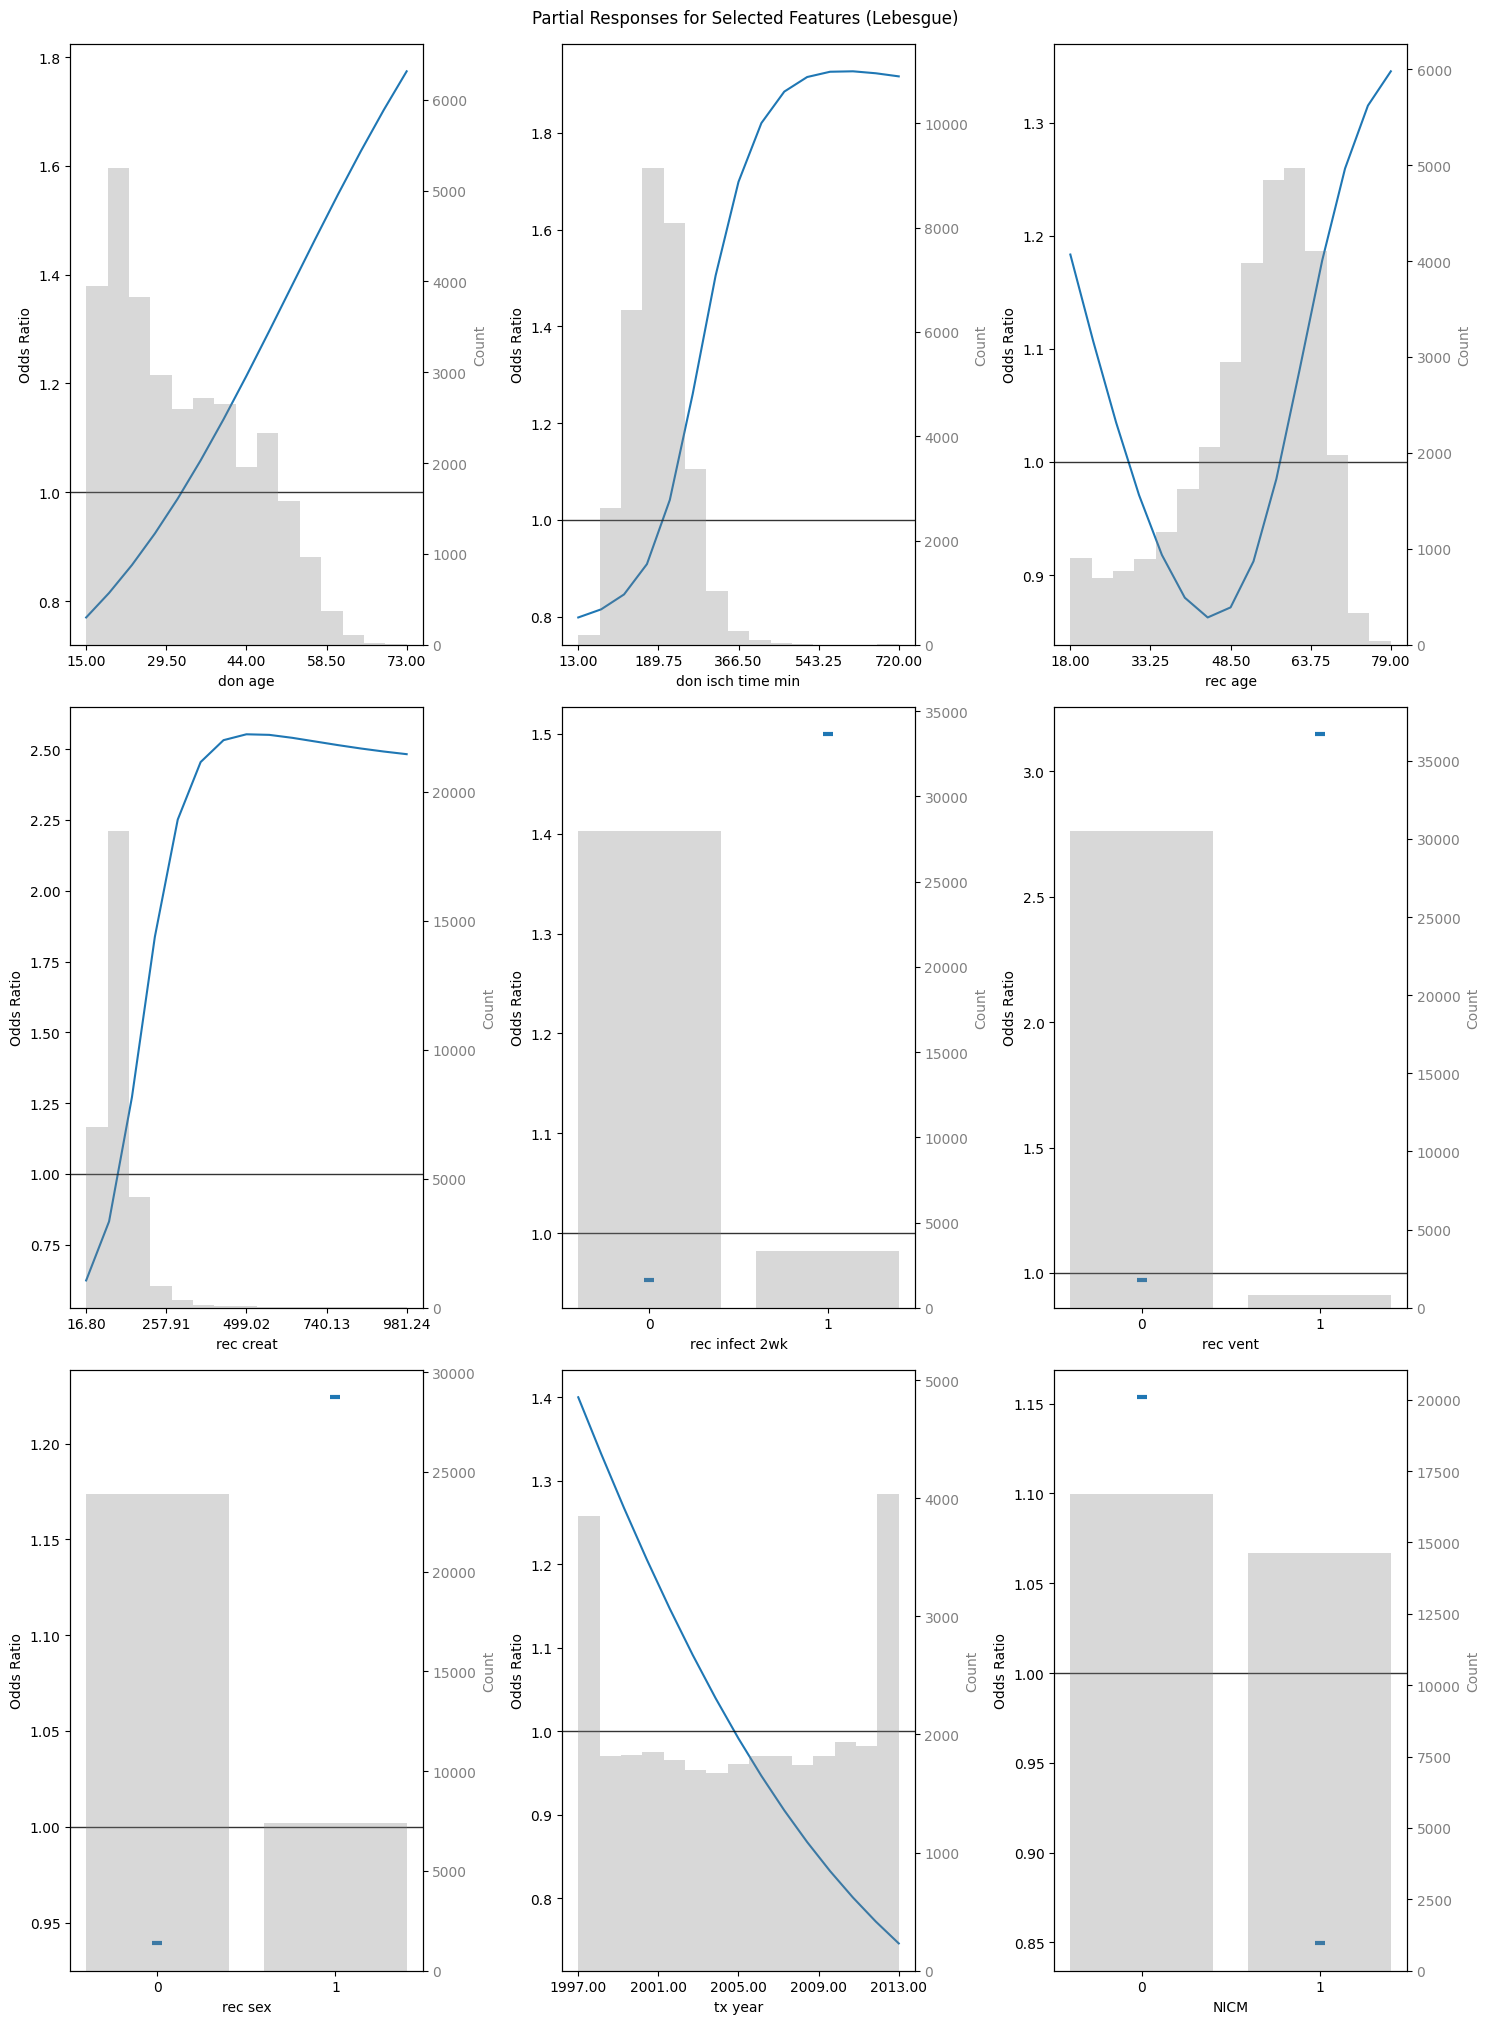

In [26]:
fig_prn = plot_partial_responses(
    lasso_results_prn,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    partial_response_network,
    n_steps=15,
    sd_scale=2,
    method=partial_response_method,
    device=device,
    categorical_threshold=15,
    subtract_univariate=True,
    figsize=(15,20),
    show_fig=True,
    return_fig=True,
    use_odds_ratio=True
)

Finally, we generate a nomogram for our PRN, based on the features selected with LASSO. The nomogram provides a visual tool that can be used to understand the model's decisions.

In [27]:
%%capture
# ^ Supress nomogram plot output, will display side-by-side instead

nomogram_params_prn = {
    'n_steps': 15,
    'sd_scale': 2,
    'method': partial_response_method,
    'device': device,
    'categorical_threshold': 15,
    'subtract_univariate': True,
    'show_fig': False,
    'return_fig': True,
    'use_odds_ratio': True
}

nomogram_results_prn = nomogram(
    lasso_results_prn,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    partial_response_network,
    **nomogram_params_prn
)

nomogram_main_prn = nomogram_results_prn[6]
nomogram_non_mixed_prn = nomogram_results_prn[7]

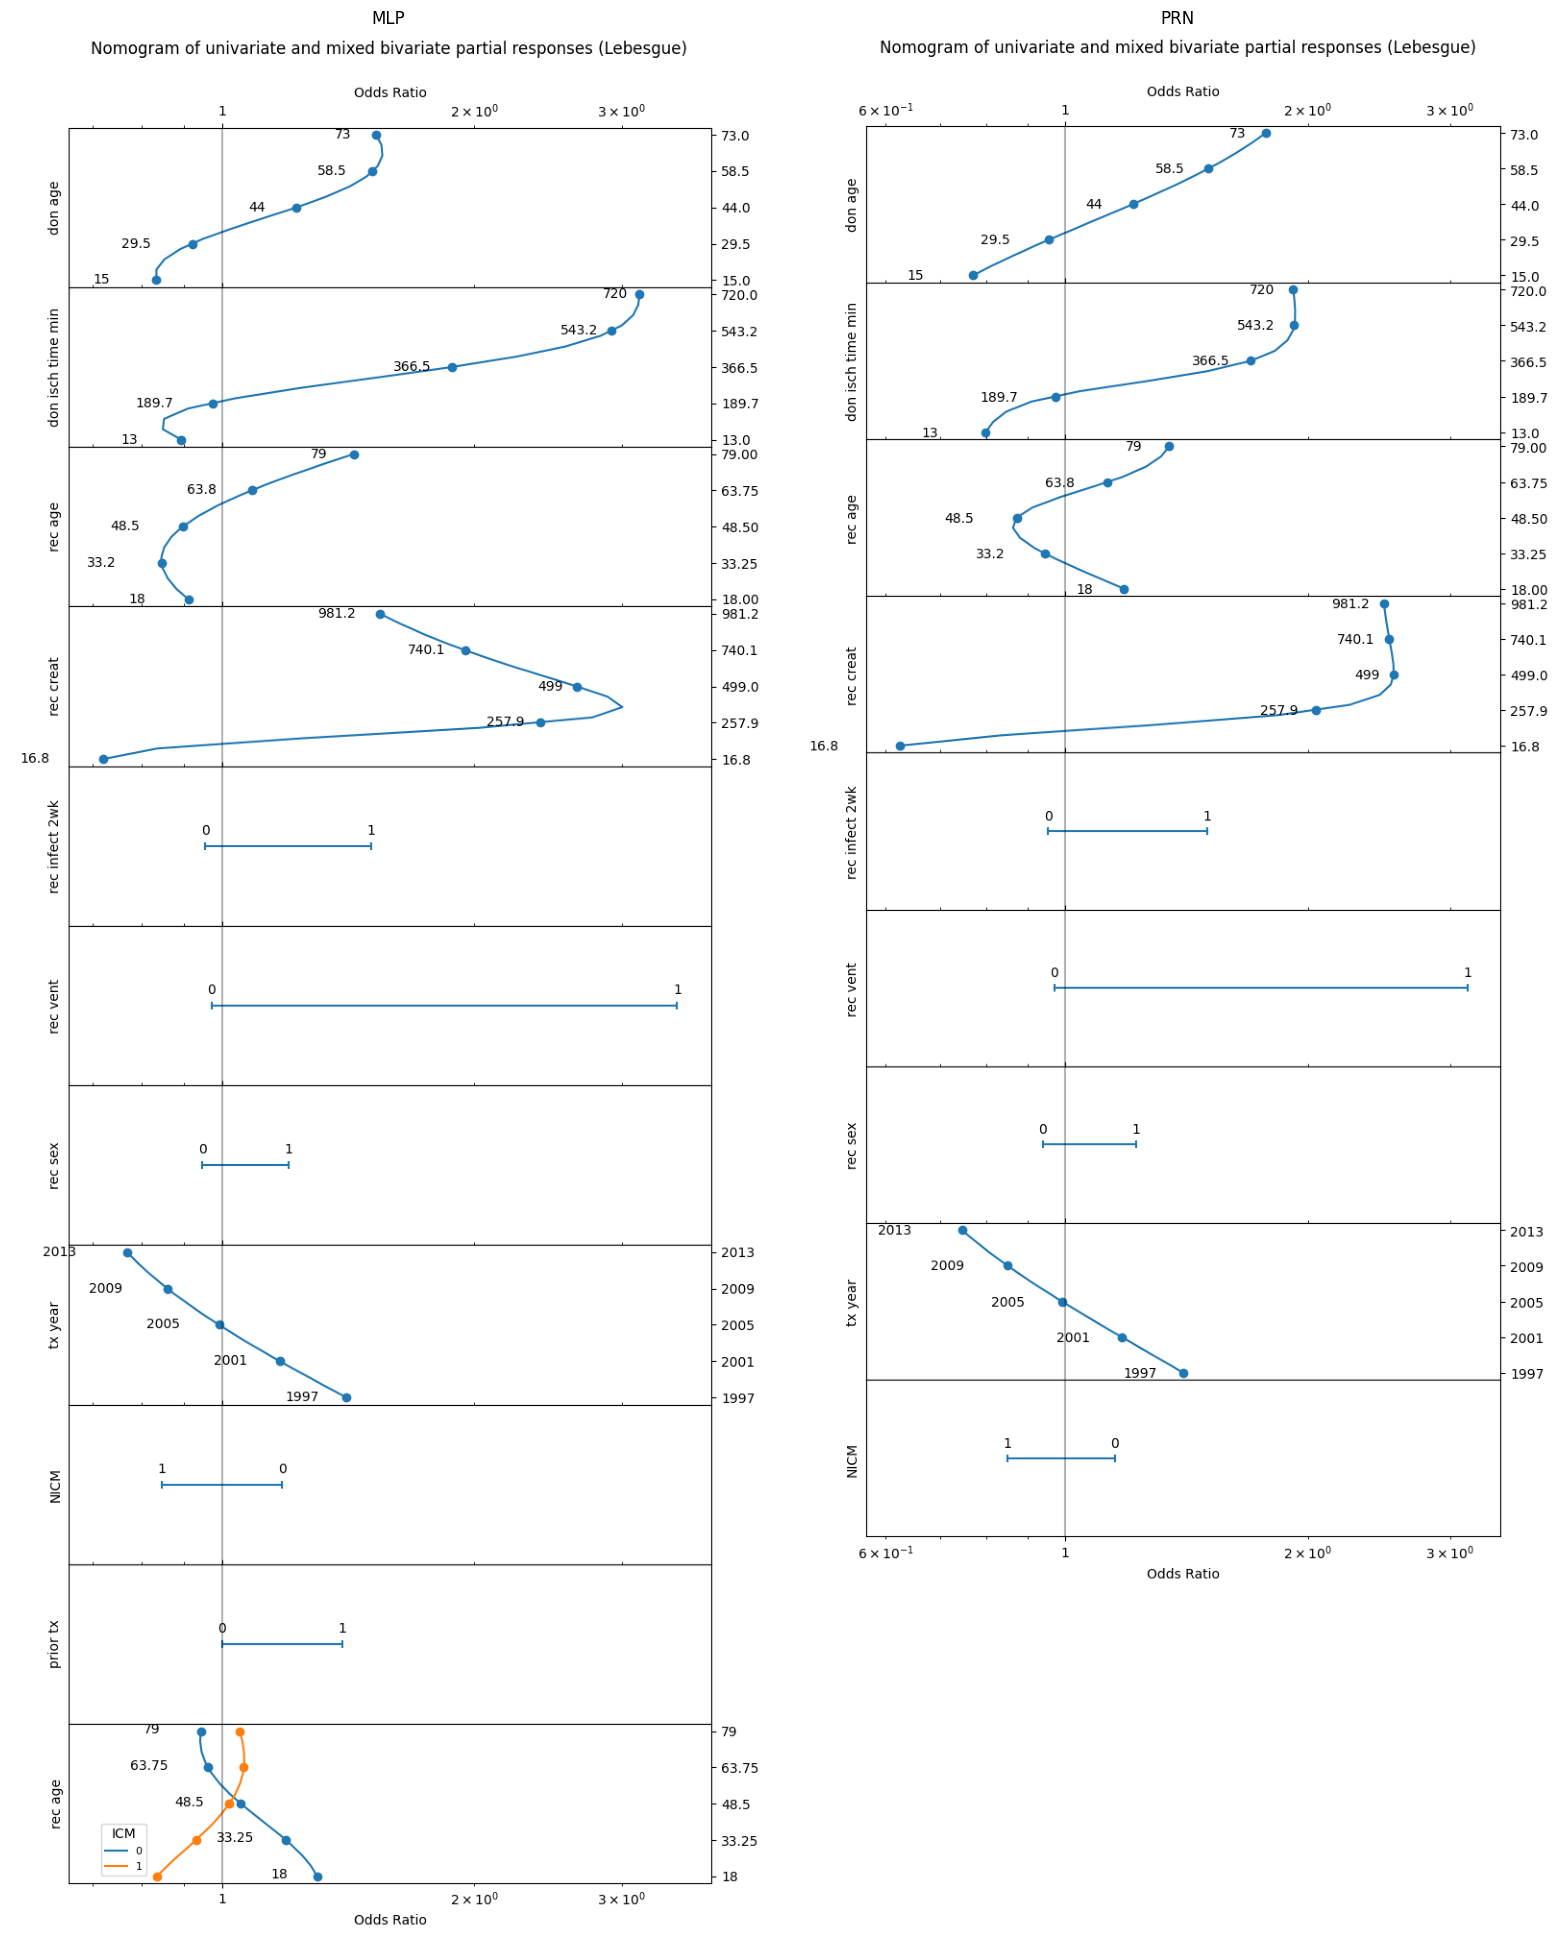

In [28]:
display_nomograms_side_by_side(nomogram_main_mlp, nomogram_non_mixed_mlp,
                               nomogram_main_prn, nomogram_non_mixed_prn)

## 11. Evaluate PRN-LASSO Model

Finally, we evaluate the simplified model (multivariate logistic regression with LASSO regularization) trained on the partial responses of the PRN, based on the selected lambda.

This notebook demonstrates the PRiSM method, transforming a black box model into an interpretable one without sacrificing predictive performance. This approach is particularly valuable when understanding the model's decision-making process is crucial for building trust and gaining insights in clinical decision-making scenarios like predicting one-year mortality after heart transplantation.

The final PRN-LASSO model provides both high predictive accuracy and interpretability, allowing us to understand how different features contribute to the predictions of post-transplant mortality risk.

In [29]:
prn_lasso = lasso_results_prn.get_selected_model()

Logistic regression model for Lambda index 20 (15.46) selected.



---- Model Performance Metrics PRN LASSO - train data ----
Threshold (prevalence) set to: 0.123
AUROC:		0.651 (95% CI: 0.642-0.660) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.643 (Proportion of correct predictions)
Precision:	0.186 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.563 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.280 (Harmonic mean of precision and recall)
--------------------------------------------


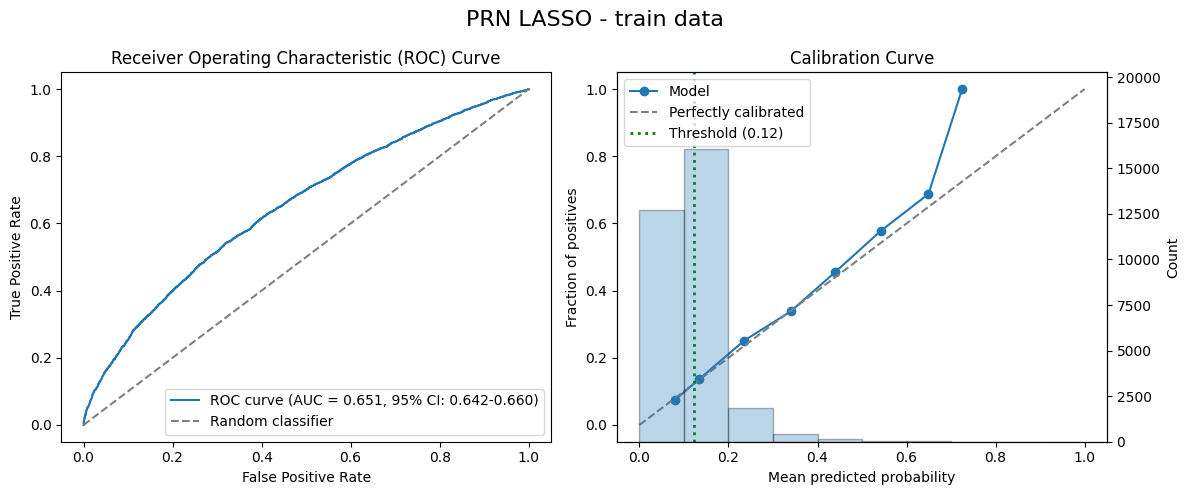


-------- Model Performance Comparison --------
Threshold (prevalence) set to: 0.123

PRN:
AUROC:		0.602 (95% CI: 0.579-0.626)
Accuracy:	0.803
Precision:	0.174
Recall:		0.223
F1 Score:	0.195

PRN LASSO:
AUROC:		0.604 (95% CI: 0.579-0.627)
Accuracy:	0.893
Precision:	0.000
Recall:		0.000
F1 Score:	0.000
------------------------------------------------


c:\Users\localuser\PRiSM\prism_github\venv_prism\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


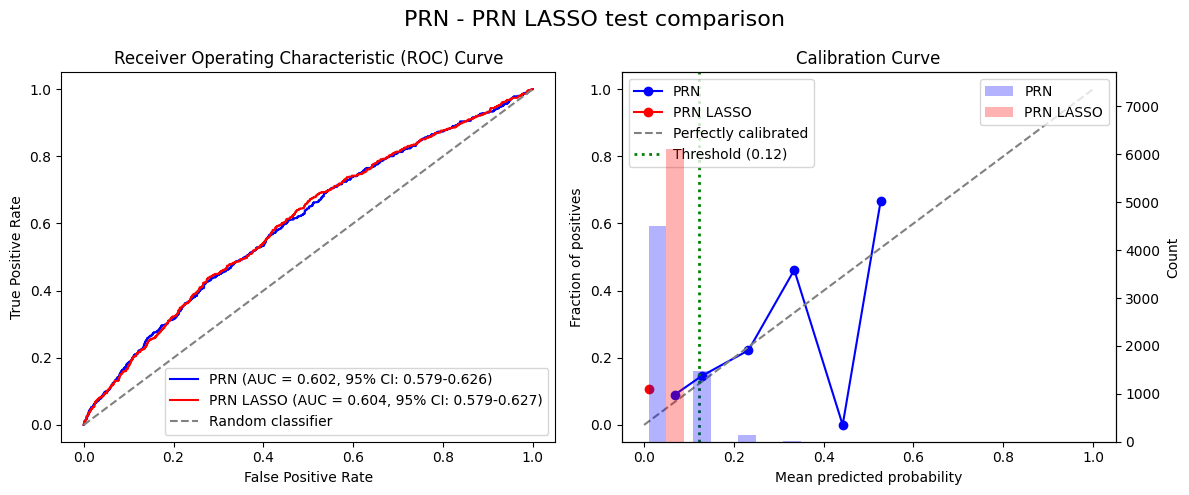


-------- Model Performance Comparison --------
Threshold (prevalence) set to: 0.123

MLP:
AUROC:		0.601 (95% CI: 0.578-0.623)
Accuracy:	0.797
Precision:	0.175
Recall:		0.241
F1 Score:	0.203

PRN LASSO:
AUROC:		0.604 (95% CI: 0.582-0.628)
Accuracy:	0.893
Precision:	0.000
Recall:		0.000
F1 Score:	0.000
------------------------------------------------


c:\Users\localuser\PRiSM\prism_github\venv_prism\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


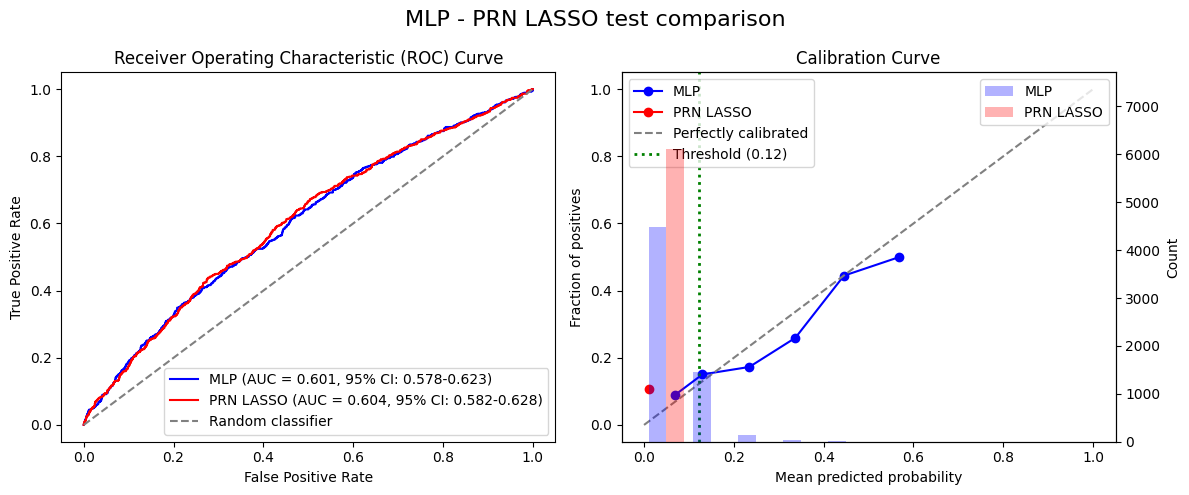

In [30]:
# Evaluate PRN-LASSO on training data
y_pred_train_prn_lasso = prn_lasso.predict_proba(partial_responses_train_prn)[:, 1]

results_prn_lasso_train = evaluate_model_performance(y_train, y_pred_train_prn_lasso, y_train, title="PRN LASSO - train data")

# Evaluate PRN-LASSO on test data and compare to PRN
y_pred_test_prn_lasso = prn_lasso.predict_proba(partial_responses_test_prn)[:, 1]

results_prn_prn_lasso_test = compare_model_performance(y_test, y_pred_test_prn, y_pred_test_prn_lasso, y_train=y_train, model_names=("PRN","PRN LASSO"), title="PRN - PRN LASSO test comparison")

# Compare PRN-LASSO and original MLP (blackbox) model
results_prn_mlp_test = compare_model_performance(y_test, y_pred_test_blackbox, y_pred_test_prn_lasso, y_train=y_train, model_names=("MLP","PRN LASSO"), title="MLP - PRN LASSO test comparison")


In [31]:
# Calculate partial responses on validation dataset
partial_responses_val_prn = partial_responses(X_val_tensor, partial_response_network, **partial_responses_params_prn)

Main compute device: cuda
Max threads: 1
Batch size: 256
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Univariate 10,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 0,10,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 1,10,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 2,10,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Biva


-------- Model Performance Comparison --------
Threshold (prevalence) set to: 0.123

PRN:
AUROC:		0.606 (95% CI: 0.578-0.633)
Accuracy:	0.580
Precision:	0.130
Recall:		0.569
F1 Score:	0.212

PRN LASSO:
AUROC:		0.604 (95% CI: 0.577-0.631)
Accuracy:	0.182
Precision:	0.105
Recall:		0.960
F1 Score:	0.189
------------------------------------------------


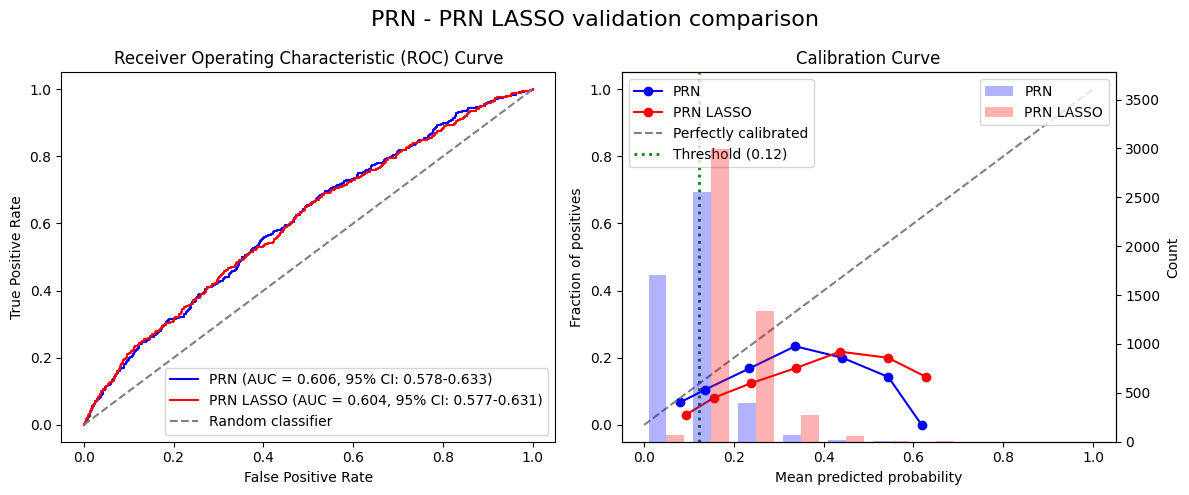

In [32]:
# Evaluate PRN-LASSO on validation dataset and compare to PRN
y_pred_val_prn = partial_response_network.predict(X_val_tensor, device=device)
y_pred_val_prn_lasso = prn_lasso.predict_proba(partial_responses_val_prn)[:, 1]


results_prn_prn_lasso_test = compare_model_performance(y_val, y_pred_val_prn, y_pred_val_prn_lasso, y_train=y_train, model_names=("PRN","PRN LASSO"), title="PRN - PRN LASSO validation comparison")